# Pearls AQI Predictor — Exploratory Data Analysis

Cross-city EDA over the backfilled feature store (`data/<city>_features.parquet`, or the Hopsworks feature groups if configured) for all 5 configured cities: Lahore, Islamabad, Rawalpindi, Karachi, Peshawar.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from config import CITIES
from src.feature_store.store import read_features

pd.set_option('display.max_columns', 50)
cities = list(CITIES)
data = {city: read_features(city) for city in cities}
for city, df in data.items():
    print(f"{city:<12} rows={len(df):>6}  range={df.index.min()} -> {df.index.max()}")

lahore       rows=  8880  range=2025-08-28 00:00:00 -> 2026-09-01 23:00:00
islamabad    rows=  8880  range=2025-08-28 00:00:00 -> 2026-09-01 23:00:00
rawalpindi   rows=  8880  range=2025-08-28 00:00:00 -> 2026-09-01 23:00:00
karachi      rows=  8880  range=2025-08-28 00:00:00 -> 2026-09-01 23:00:00
peshawar     rows=  8880  range=2025-08-28 00:00:00 -> 2026-09-01 23:00:00


## 1. AQI time series per city

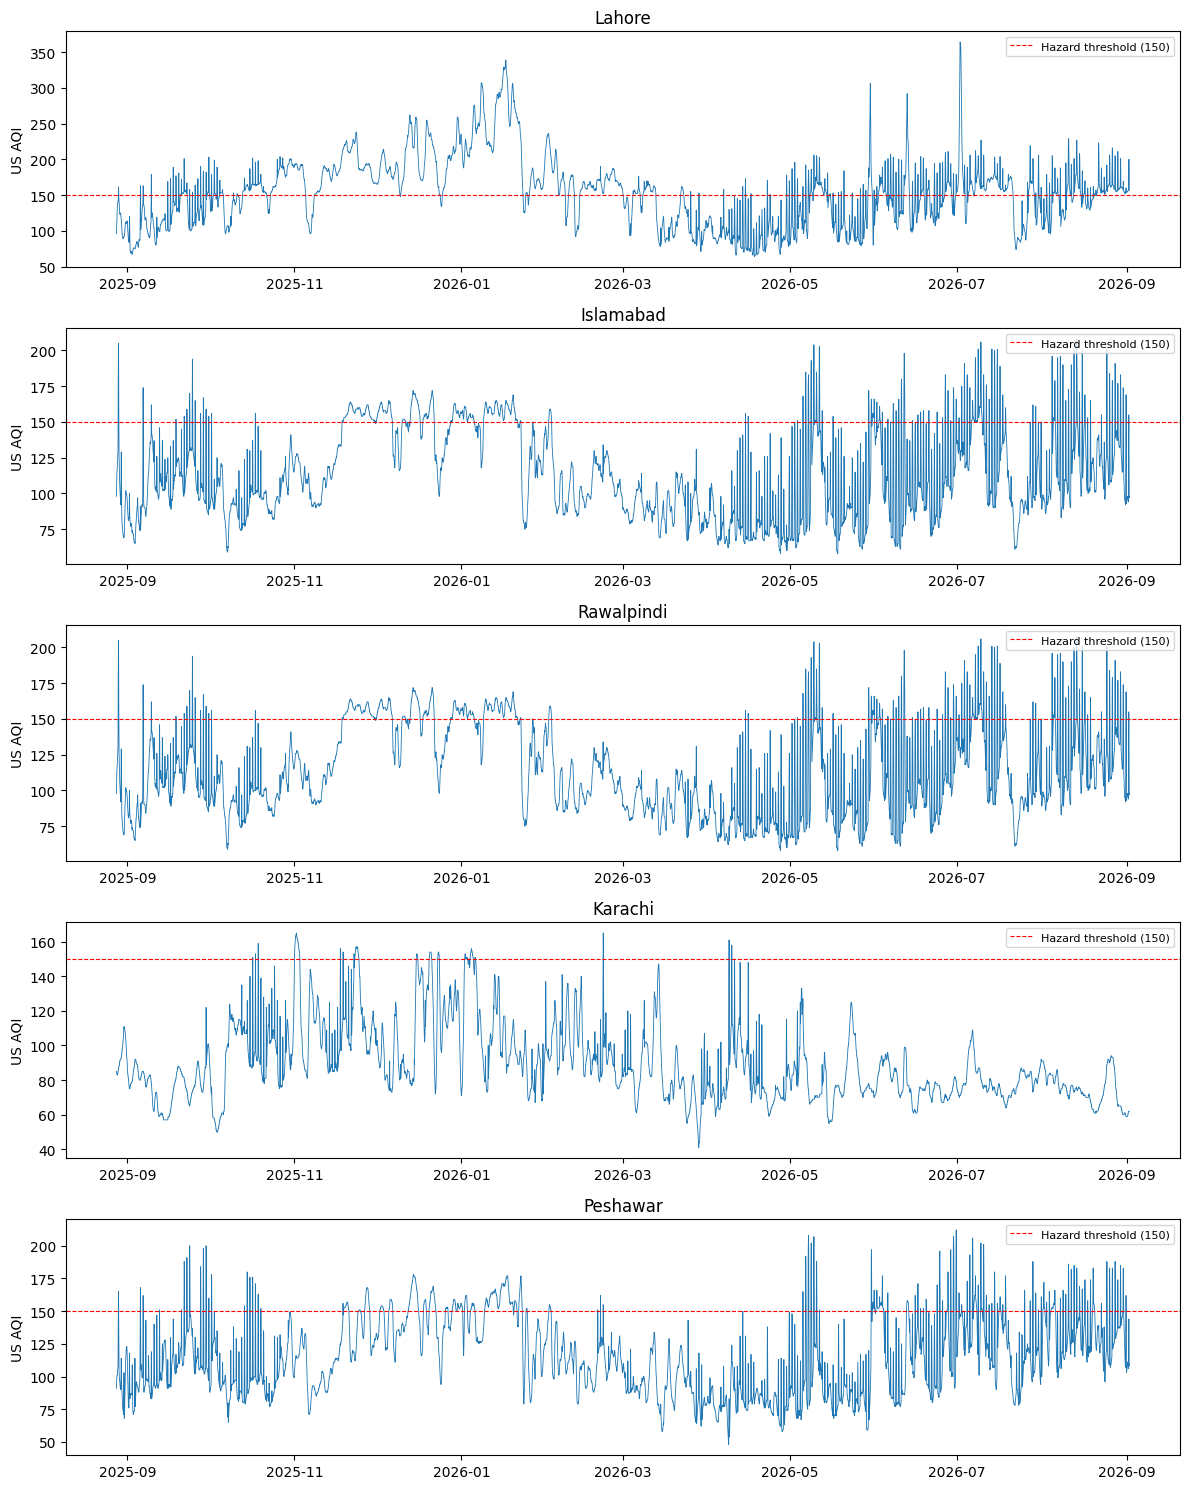

In [2]:
fig, axes = plt.subplots(len(cities), 1, figsize=(12, 3 * len(cities)), sharex=False)
for ax, city in zip(axes, cities):
    df = data[city]
    ax.plot(df.index, df['us_aqi'], linewidth=0.6)
    ax.axhline(150, color='red', linestyle='--', linewidth=0.8, label='Hazard threshold (150)')
    ax.set_title(city.title())
    ax.set_ylabel('US AQI')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 2. Summary statistics per city

In [3]:
summary = pd.DataFrame({
    city: df['us_aqi'].describe()
    for city, df in data.items()
}).T
summary

,count,mean,std,min,25%,50%,75%,max
lahore,8880.0,154.695833,48.138285,64.0,118.0,156.0,179.25,364.0
islamabad,8880.0,113.841216,30.816267,58.0,90.0,108.0,141.00,208.0
rawalpindi,8880.0,113.841216,30.816267,58.0,90.0,108.0,141.00,208.0
karachi,8880.0,89.478153,22.020692,41.0,74.0,84.0,100.00,165.0
peshawar,8880.0,115.635811,29.115791,48.0,91.0,113.0,138.00,212.0


## 3. Seasonality: AQI by month and hour of day

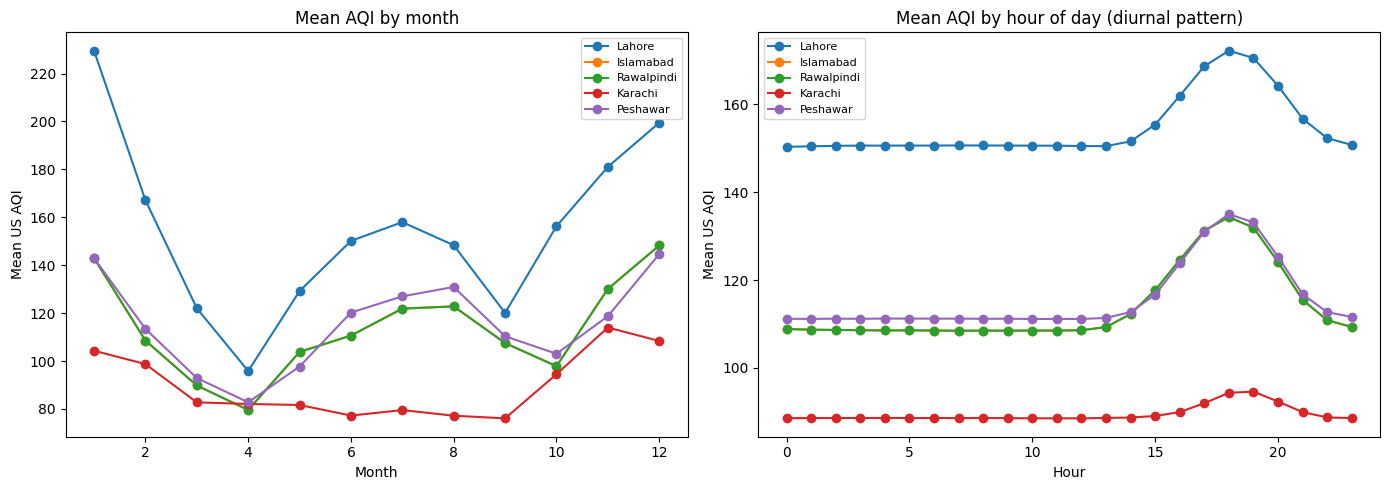

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for city, df in data.items():
    monthly = df.groupby('month')['us_aqi'].mean()
    axes[0].plot(monthly.index, monthly.values, marker='o', label=city.title())
    hourly = df.groupby('hour')['us_aqi'].mean()
    axes[1].plot(hourly.index, hourly.values, marker='o', label=city.title())
axes[0].set_title('Mean AQI by month')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Mean US AQI'); axes[0].legend(fontsize=8)
axes[1].set_title('Mean AQI by hour of day (diurnal pattern)')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Mean US AQI'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Pollutant / weather correlation with AQI (Lahore)

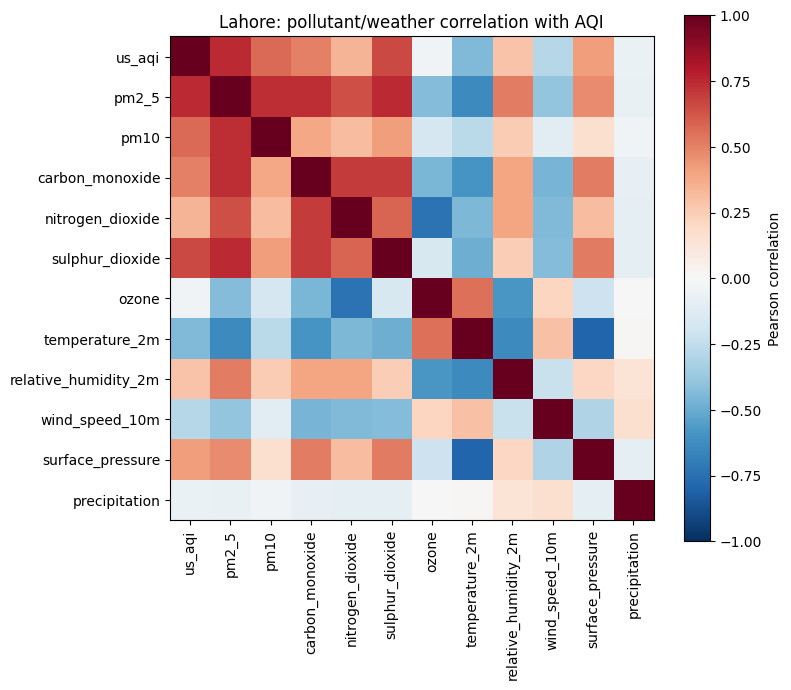

us_aqi                  1.000000
pm2_5                   0.748242
sulphur_dioxide         0.658377
pm10                    0.569865
carbon_monoxide         0.505972
surface_pressure        0.414448
nitrogen_dioxide        0.339053
relative_humidity_2m    0.285208
ozone                  -0.037481
precipitation          -0.064849
wind_speed_10m         -0.285948
temperature_2m         -0.439662
Name: us_aqi, dtype: float64

In [5]:
cols = ['us_aqi', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide',
        'sulphur_dioxide', 'ozone', 'temperature_2m', 'relative_humidity_2m',
        'wind_speed_10m', 'surface_pressure', 'precipitation']
corr = data['lahore'][cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
fig.colorbar(im, label='Pearson correlation')
ax.set_title('Lahore: pollutant/weather correlation with AQI')
plt.tight_layout()
plt.show()
corr['us_aqi'].sort_values(ascending=False)

## 5. AQI category distribution per city

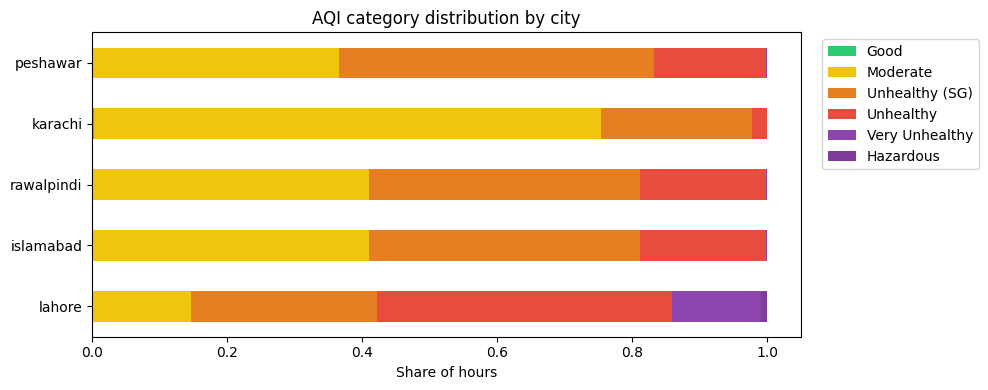

us_aqi,Good,Moderate,Unhealthy (SG),Unhealthy,Very Unhealthy,Hazardous
lahore,0.000000,0.146734,0.275000,0.437162,0.130968,0.010135
islamabad,0.000000,0.409572,0.401126,0.187050,0.002252,0.000000
rawalpindi,0.000000,0.409572,0.401126,0.187050,0.002252,0.000000
karachi,0.003153,0.751014,0.223649,0.022185,0.000000,0.000000
peshawar,0.000225,0.365541,0.466892,0.164977,0.002365,0.000000


In [6]:
def category(aqi):
    for hi, name in [(50, 'Good'), (100, 'Moderate'), (150, 'Unhealthy (SG)'),
                     (200, 'Unhealthy'), (300, 'Very Unhealthy'), (10**9, 'Hazardous')]:
        if aqi <= hi:
            return name

order = ['Good', 'Moderate', 'Unhealthy (SG)', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
dist = pd.DataFrame({
    city: df['us_aqi'].apply(category).value_counts(normalize=True).reindex(order).fillna(0)
    for city, df in data.items()
}).T[order]

ax = dist.plot(kind='barh', stacked=True, figsize=(10, 4),
                color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad', '#7d3c98'])
ax.set_xlabel('Share of hours')
ax.set_title('AQI category distribution by city')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
dist

## 6. Change-rate distribution (how fast does AQI move hour to hour?)

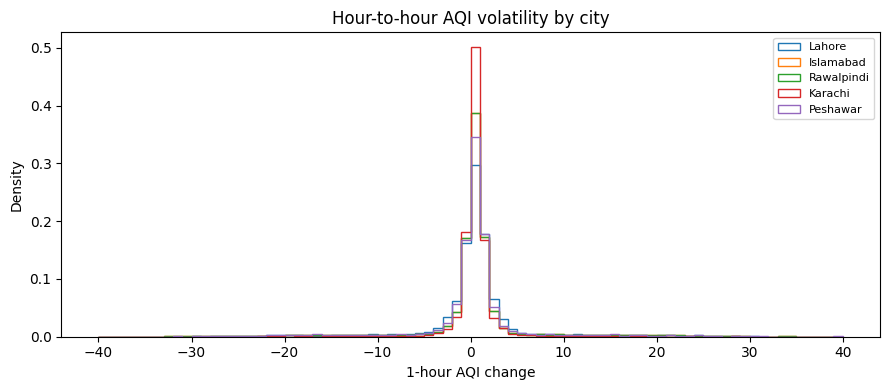

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for city, df in data.items():
    ax.hist(df['aqi_change_1h'].dropna(), bins=80, range=(-40, 40),
            histtype='step', label=city.title(), density=True)
ax.set_xlabel('1-hour AQI change'); ax.set_ylabel('Density')
ax.set_title('Hour-to-hour AQI volatility by city')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Takeaways

- Lahore and the Punjab cities (Islamabad, Rawalpindi) show a much wider AQI range and heavier right tail than Karachi, whose AQI stays mostly in the Good/Moderate band year-round.
- All cities show a clear diurnal pattern (spikes tied to traffic/cooking hours) and a seasonal pattern (worse AQI in the winter months, consistent with regional smog patterns).
- `pm2_5`/`pm10` correlate most strongly with `us_aqi` (expected, since US AQI for these cities is usually PM-dominated); wind speed correlates negatively (wind disperses pollutants).
- These findings motivated the lag/rolling/change-rate features and the future-weather features used at serving time (see `src/features/engineering.py`) and are discussed further in `report/report.md`.